In [1]:
import os, sys, random
import numpy as np
import pandas as pd
import torch

%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath("../src"))

from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

TRAIN_START, TRAIN_END = "2022-01-01", "2024-12-31"
TEST_START,  TEST_END  = "2025-01-01", "2025-12-31"

TIMEFRAMES = ["1m", "5m", "15m", "60m"]

def make_cfg(interval, symbol="QQQ", source="alpaca", start=TRAIN_START, end="2025-12-31"):
    return DataCleanerConfig(source=source, symbol=symbol, interval=interval, start_date=start, end_date=end)

cfg = make_cfg("5m")
print(cfg)
print("splits:", (TRAIN_START, TRAIN_END), (TEST_START, TEST_END))

device: cpu
splits: ('2022-01-01', '2024-12-31') ('2025-01-01', '2025-12-31')


In [3]:
cleaner = DataCleaner(cfg)
df = preprocess_data(cleaner.cargar_datos())

time_col = "datetime" if "datetime" in df.columns else "timestamp"
df[time_col] = pd.to_datetime(df[time_col], utc=True).dt.tz_convert(None)
df = df.set_index(time_col).sort_index()

train_df = df.loc[TRAIN_START:TRAIN_END].copy()
test_df  = df.loc[TEST_START:TEST_END].copy()

print("full:", df.index.min(), "->", df.index.max(), "|", df.shape)
print("train:", train_df.shape, "| test:", test_df.shape)
train_df.tail()


full: 2022-01-03 10:40:00 -> 2025-12-31 00:00:00 | (189128, 17)
train: (141583, 17) | test: (47545, 17)


,symbol,open,high,low,close,volume,trade_count,vwap,volume_norm,return,log_return_raw,log_return_close,log_return_norm,log_ret_oc,log_ret_hl,log_ret_ch,log_ret_cl
datetime,,,,,,,,,,,,,,,,,
2024-12-31 23:30:00,QQQ,511.3700,511.40,511.3700,511.40,485.0,26.0,511.378333,-0.557125,0.000282,6.237152,0.000282,1.508489,0.000059,0.000059,0.000000,0.000059
2024-12-31 23:35:00,QQQ,511.2553,511.30,511.2553,511.30,383.0,13.0,511.287229,-0.549686,-0.000196,6.236957,-0.000196,-0.970032,0.000087,0.000087,0.000000,0.000087
2024-12-31 23:40:00,QQQ,511.2900,511.29,511.2900,511.29,129.0,9.0,511.290000,-0.497104,-0.000020,6.236937,-0.000020,0.128370,0.000000,0.000000,0.000000,0.000000
2024-12-31 23:45:00,QQQ,511.2500,511.25,511.2300,511.23,1398.0,55.0,511.232008,-0.344397,-0.000117,6.236820,-0.000117,-0.574895,-0.000039,0.000039,-0.000039,0.000000
2024-12-31 23:50:00,QQQ,511.2000,511.20,511.1800,511.18,870.0,67.0,511.193333,-0.329203,-0.000098,6.236722,-0.000098,-0.365089,-0.000039,0.000039,-0.000039,0.000000


In [4]:
from sklearn.model_selection import TimeSeriesSplit

LOOKBACK = 64  # luego lo tocamos según timeframe

# features numéricas (quitamos symbol si está)
feature_cols = [c for c in train_df.columns if pd.api.types.is_numeric_dtype(train_df[c])]
if "symbol" in feature_cols: feature_cols.remove("symbol")

# target: retorno próximo (1 vela) del close
def add_target(d):
    d = d.copy()
    d["y"] = d["close"].pct_change().shift(-1)
    return d.dropna()

def make_sequences(d, cols, lookback):
    Xv = d[cols].to_numpy(dtype=np.float32)
    yv = d["y"].to_numpy(dtype=np.float32)
    idx = d.index.to_numpy()

    X, y, t = [], [], []
    for i in range(lookback, len(d)):
        X.append(Xv[i-lookback:i])
        y.append(yv[i])
        t.append(idx[i])
    return np.array(X), np.array(y), np.array(t)

train_s = add_target(train_df)
test_s  = add_target(pd.concat([train_df.tail(LOOKBACK), test_df]))  # contexto para inicio 2025

X_train, y_train, t_train = make_sequences(train_s, feature_cols, LOOKBACK)
X_test,  y_test,  t_test  = make_sequences(test_s,  feature_cols, LOOKBACK)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:",  X_test.shape,  "y_test:",  y_test.shape)

tscv = TimeSeriesSplit(n_splits=5)
print("folds:", tscv.get_n_splits())


X_train: (141518, 64, 16) y_train: (141518,)
X_test: (47544, 64, 16) y_test: (47544,)
folds: 5


In [5]:
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

class LSTMReg(nn.Module):
    def __init__(self, n_features, hidden=32, layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, layers, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1]).squeeze(-1)

def scale_3d(X_fit, X_apply):
    sc = StandardScaler()
    a = X_fit.reshape(-1, X_fit.shape[-1])
    sc.fit(a)
    def tr(Z): return sc.transform(Z.reshape(-1, Z.shape[-1])).reshape(Z.shape)
    return tr(X_fit), tr(X_apply), sc

def fit_model(Xtr, ytr, Xva, yva, hidden=32, lr=1e-3, epochs=3, bs=512):
    Xtr, Xva, _ = scale_3d(Xtr, Xva)

    model = LSTMReg(Xtr.shape[-1], hidden=hidden).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    tr_loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)), batch_size=bs, shuffle=False)

    for _ in range(epochs):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(Xva).to(device)).cpu().numpy()
    val_mse = float(((pred - yva) ** 2).mean())
    return val_mse, model.state_dict()

# ---- CV
HIDDEN, LR, EPOCHS, BS = 32, 1e-3, 3, 512

fold_mse = []
best = (1e18, None)

for k, (tr_idx, va_idx) in enumerate(tscv.split(X_train), 1):
    mse, state = fit_model(X_train[tr_idx], y_train[tr_idx], X_train[va_idx], y_train[va_idx],
                           hidden=HIDDEN, lr=LR, epochs=EPOCHS, bs=BS)
    fold_mse.append(mse)
    if mse < best[0]: best = (mse, state)
    print(f"fold {k}: val_mse={mse:.6g}")

print("mean val_mse:", np.mean(fold_mse), "| best:", best[0])


fold 1: val_mse=5.11474e-05
fold 2: val_mse=0.000100156
fold 3: val_mse=3.76943e-05
fold 4: val_mse=0.000242005
fold 5: val_mse=3.44902e-05
mean val_mse: 9.309861270594411e-05 | best: 3.4490221878513694e-05


thr: 0.010044409 | entries: 1007
final strat: 1.0202237 | maxDD: -0.1369375
final buy&hold: 1.210451 | maxDD: -0.2527274


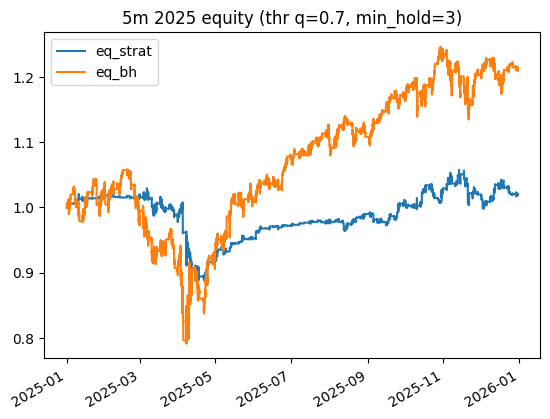

In [6]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- escalar (fit en train completo), entrenar, predecir test
sc = StandardScaler().fit(X_train.reshape(-1, X_train.shape[-1]))
Xtr = sc.transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
Xte = sc.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

model = LSTMReg(Xtr.shape[-1], hidden=HIDDEN).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(y_train)), batch_size=BS, shuffle=False)

for _ in range(EPOCHS):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        opt.step()

model.eval()
with torch.no_grad():
    pred = model(torch.tensor(Xte).to(device)).cpu().numpy()

# --- backtest 2025 (NY 07:45-12:00) + umbral + min_hold
Q_THR = 0.70      # 0.60-0.85 suele ser el rango a probar
MIN_HOLD = 3      # velas mínimas dentro (5m -> 15min). luego lo tocamos.

with torch.no_grad():
    pred_tr = model(torch.tensor(Xtr).to(device)).cpu().numpy()

thr = np.quantile(np.abs(pred_tr), Q_THR)

bt = pd.DataFrame({"pred": pred, "y": y_test}, index=pd.to_datetime(t_test))
bt = bt.loc[TEST_START:TEST_END].copy()

idx_utc = bt.index.tz_localize("UTC") if bt.index.tz is None else bt.index
idx_ny = idx_utc.tz_convert("America/New_York")
t = idx_ny.time
allowed = (t >= pd.to_datetime("07:45").time()) & (t <= pd.to_datetime("12:00").time())

predv = bt["pred"].to_numpy()
pos = np.zeros(len(bt), dtype=np.int8)

p, hold = 0, 0
for i in range(len(bt)):
    s = 0 if abs(predv[i]) <= thr else int(np.sign(predv[i]))

    if p == 0:
        if allowed[i] and s != 0:
            p, hold = s, 0
    else:
        hold += 1
        if not allowed[i]:
            p, hold = 0, 0
        elif hold >= MIN_HOLD and (s == 0 or s == -p):
            p, hold = 0, 0
    pos[i] = p

bt["pos"] = pos
bt["strat_ret"] = bt["pos"] * bt["y"]
bt["bh_ret"] = bt["y"]

bt["eq_strat"] = (1 + bt["strat_ret"]).cumprod()
bt["eq_bh"]    = (1 + bt["bh_ret"]).cumprod()

entries = int(((bt["pos"] != 0) & (bt["pos"].shift(1).fillna(0) == 0)).sum())

def max_dd(eq):
    peak = eq.cummax()
    return ((eq/peak) - 1).min()

print("thr:", thr, "| entries:", entries)
print("final strat:", bt["eq_strat"].iloc[-1], "| maxDD:", max_dd(bt["eq_strat"]))
print("final buy&hold:", bt["eq_bh"].iloc[-1], "| maxDD:", max_dd(bt["eq_bh"]))

bt[["eq_strat","eq_bh"]].plot(title=f"{cfg.interval} 2025 equity (thr q={Q_THR}, min_hold={MIN_HOLD})")
plt.show()


entries: 1007 | avg_hold(bars): 6.18
ann_ret: 1.4 % | sharpe: 0.22
maxDD: -0.1369
final gross: 1.020224 | final net: 0.83411


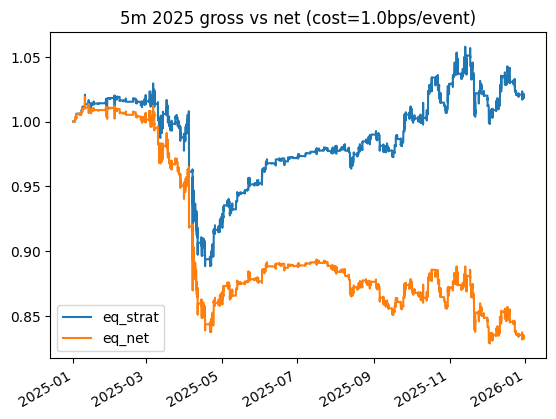

In [7]:
# métricas básicas
ret = bt["strat_ret"]
eq  = bt["eq_strat"]

# trades / holding
pos = bt["pos"].fillna(0).astype(int)
chg = pos.diff().fillna(pos).abs()                 # 1 en entry y 1 en exit
entries = int(((pos != 0) & (pos.shift(1).fillna(0) == 0)).sum())

# duración media de trades (en velas)
seg_id = (pos != pos.shift(1)).cumsum()
holds = pos.ne(0).groupby(seg_id).sum()
avg_hold = float(holds[holds > 0].mean()) if (holds > 0).any() else 0.0

# daily stats (para sharpe)
daily = ret.resample("1D").sum().dropna()
ann_ret = (eq.iloc[-1] ** (252 / max(1, len(daily))) - 1)
sharpe = (daily.mean() / (daily.std() + 1e-12)) * np.sqrt(252)

# costes simples por evento (entry/exit), en bps
COST_BPS = 1.0   # prueba 0.5 / 1 / 2
cost = (COST_BPS / 1e4) * chg
ret_net = ret - cost
eq_net = (1 + ret_net).cumprod()

def max_dd(eq_):
    peak = eq_.cummax()
    return ((eq_/peak) - 1).min()

print("entries:", entries, "| avg_hold(bars):", round(avg_hold, 2))
print("ann_ret:", round(ann_ret*100, 2), "% | sharpe:", round(float(sharpe), 2))
print("maxDD:", round(float(max_dd(eq)), 4))
print("final gross:", round(float(eq.iloc[-1]), 6), "| final net:", round(float(eq_net.iloc[-1]), 6))

bt[["eq_strat"]].assign(eq_net=eq_net).plot(title=f"{cfg.interval} 2025 gross vs net (cost={COST_BPS}bps/event)")
plt.show()


In [10]:
# CELDA 7 — loop por timeframes (SIN reventar RAM) + fix Alpaca 60m -> 1h

import gc
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

torch.set_num_threads(2)

class SeqDS(Dataset):
    def __init__(self, X2d, y, lb):
        self.X = torch.tensor(X2d, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.lb = lb
    def __len__(self): return len(self.y) - self.lb
    def __getitem__(self, i):
        j = i + self.lb
        return self.X[j-self.lb:j], self.y[j]

class SeqX(Dataset):
    def __init__(self, X2d, lb):
        self.X = torch.tensor(X2d, dtype=torch.float32)
        self.lb = lb
    def __len__(self): return len(self.X) - self.lb
    def __getitem__(self, i):
        j = i + self.lb
        return self.X[j-self.lb:j]

def add_target(d):
    d = d.copy()
    d["y"] = d["close"].pct_change().shift(-1)
    return d.dropna()

def predict(model, X2d, lb, bs=2048):
    dl = DataLoader(SeqX(X2d, lb), batch_size=bs, shuffle=False)
    out = []
    model.eval()
    with torch.no_grad():
        for xb in dl:
            out.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(out)

def run_tf(interval, lookback, q_thr=0.7, min_hold_min=15, cost_bps=1.0):
    # FIX Alpaca: 60m no existe, usar 1h
    interval = "1h" if interval == "60m" else interval

    cfg = make_cfg(interval, end="2025-12-31")
    df = preprocess_data(DataCleaner(cfg).cargar_datos())

    time_col = "datetime" if "datetime" in df.columns else "timestamp"
    df[time_col] = pd.to_datetime(df[time_col], utc=True).dt.tz_convert(None)
    df = df.set_index(time_col).sort_index()

    train_df = df.loc[TRAIN_START:TRAIN_END].copy()
    test_df  = df.loc[TEST_START:TEST_END].copy()

    cols = [c for c in train_df.columns if pd.api.types.is_numeric_dtype(train_df[c]) and c != "symbol"]

    tr = add_target(train_df)
    te = add_target(pd.concat([train_df.tail(lookback), test_df]))

    Xtr2 = tr[cols].to_numpy(np.float32); ytr = tr["y"].to_numpy(np.float32)
    Xte2 = te[cols].to_numpy(np.float32); yte = te["y"].to_numpy(np.float32); tte = te.index.to_numpy()

    sc = StandardScaler().fit(Xtr2)
    Xtr2 = sc.transform(Xtr2).astype(np.float32)
    Xte2 = sc.transform(Xte2).astype(np.float32)

    model = LSTMReg(Xtr2.shape[1], hidden=HIDDEN).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    dl = DataLoader(SeqDS(Xtr2, ytr, lookback), batch_size=BS, shuffle=False)
    for _ in range(EPOCHS):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

    pred_tr = predict(model, Xtr2, lookback, bs=2048)
    pred_te = predict(model, Xte2, lookback, bs=2048)
    thr = float(np.quantile(np.abs(pred_tr), q_thr))

    bt = pd.DataFrame(
        {"pred": pred_te, "y": yte[lookback:]},
        index=pd.to_datetime(tte[lookback:])
    ).loc[TEST_START:TEST_END].copy()

    idx_utc = bt.index.tz_localize("UTC") if bt.index.tz is None else bt.index
    idx_ny = idx_utc.tz_convert("America/New_York")
    tt = idx_ny.time
    allowed = (tt >= pd.to_datetime("07:45").time()) & (tt <= pd.to_datetime("12:00").time())

    tf_min = 60 if interval.endswith("h") else int(interval[:-1])
    min_hold = max(1, int(round(min_hold_min / tf_min)))

    predv = bt["pred"].to_numpy()
    pos = np.zeros(len(bt), dtype=np.int8)
    p = hold = 0
    for i in range(len(bt)):
        s = 0 if abs(predv[i]) <= thr else int(np.sign(predv[i]))
        if p == 0:
            if allowed[i] and s != 0: p, hold = s, 0
        else:
            hold += 1
            if (not allowed[i]) or (hold >= min_hold and (s == 0 or s == -p)):
                p, hold = 0, 0
        pos[i] = p

    bt["pos"] = pos
    bt["ret"] = bt["pos"] * bt["y"]
    chg = bt["pos"].diff().fillna(bt["pos"]).abs()
    bt["ret_net"] = bt["ret"] - (cost_bps/1e4) * chg
    bt["eq_gross"] = (1 + bt["ret"]).cumprod()
    bt["eq_net"]   = (1 + bt["ret_net"]).cumprod()

    entries = int(((bt["pos"] != 0) & (bt["pos"].shift(1).fillna(0) == 0)).sum())

    def max_dd(eq):
        peak = eq.cummax()
        return float(((eq/peak)-1).min())

    out = dict(tf=interval, lookback=lookback, thr=thr, entries=entries,
               gross=float(bt["eq_gross"].iloc[-1]),
               net=float(bt["eq_net"].iloc[-1]),
               dd_net=max_dd(bt["eq_net"]))

    del df, train_df, test_df, tr, te, Xtr2, Xte2, ytr, yte, dl, bt
    gc.collect()
    return out

# screening rápido (luego subimos epochs/hidden)
HIDDEN, LR, EPOCHS, BS = 16, 1e-3, 2, 1024

SAFE_TFS = ["1h", "15m", "5m"]          # (si quieres "60m", ponlo aquí y run_tf lo convierte a "1h")
LOOKBACK_MAP = {"5m": 64, "15m": 96, "1h": 48}

rows = [run_tf(tf, LOOKBACK_MAP["1h" if tf == "60m" else tf], q_thr=0.7, min_hold_min=15, cost_bps=1.0)
        for tf in SAFE_TFS]

pd.DataFrame(rows).sort_values("net", ascending=False)


ValueError: Intervalo no soportado para Alpaca: 1h